In [7]:
import os

import ipywidgets as widgets
from flax import nnx
from IPython.display import clear_output, display

from src.agent_pair import AgentPair
from src.config import Config
from src.train import eval_agent
from src.utils.checkpoint import load_model_weights
from src.utils.constants import TEST_LAYOUTS
from src.utils.visualize import plot_test_results, show_overcooked_episode

os.environ["SDL_AUDIODRIVER"] = "dummy"
SEED = 0
NUM_TEST_EPISODES = 10

## Test Results Across Layouts (Quantitative Analysis)

Select an experiment from the dropdown to load the agent and benchmark it on the test maps.

In [ ]:
cfg: Config = Config.from_files(
    config_paths=["../configs/optimized.yaml"],
    overrides={"video_dir": None, "checkpoint_dir": "../checkpoints", "env_config": {"layouts": TEST_LAYOUTS}},
)
eval_envs = cfg.eval_envs

experiments = [p.name for p in cfg.checkpoint_dir.iterdir() if p.is_dir()]

dd_experiments = widgets.Dropdown(options=experiments, description="Exp:", layout=widgets.Layout(width="400px"))

btn_load = widgets.Button(
    description="Load Model",
    button_style="primary",
    icon="upload",
)

out_log = widgets.Output()


def model_factory():
    return AgentPair(cfg.training_config, eval_envs, nnx.Rngs(SEED))


def on_load_click(b):
    global agent_pair

    with out_log:
        clear_output()
        exp_name = dd_experiments.value
        print("📂 Loading agent from:", exp_name)

        model_path = cfg.checkpoint_dir / exp_name
        agent_pair = load_model_weights(model_factory, model_path)


btn_load.on_click(on_load_click)

display(widgets.VBox([widgets.HBox([dd_experiments, btn_load]), out_log]))

2026-01-24 19:34:50.632 | INFO     | src.config.config:from_files:155 - 📄 Building config from 1 files:
2026-01-24 19:34:50.632 | INFO     | src.config.config:from_files:157 -     -> Loading: optimized.yaml
/home/aarcara/aas_project/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/aarcara/aas_project/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/aarcara/aas_pro

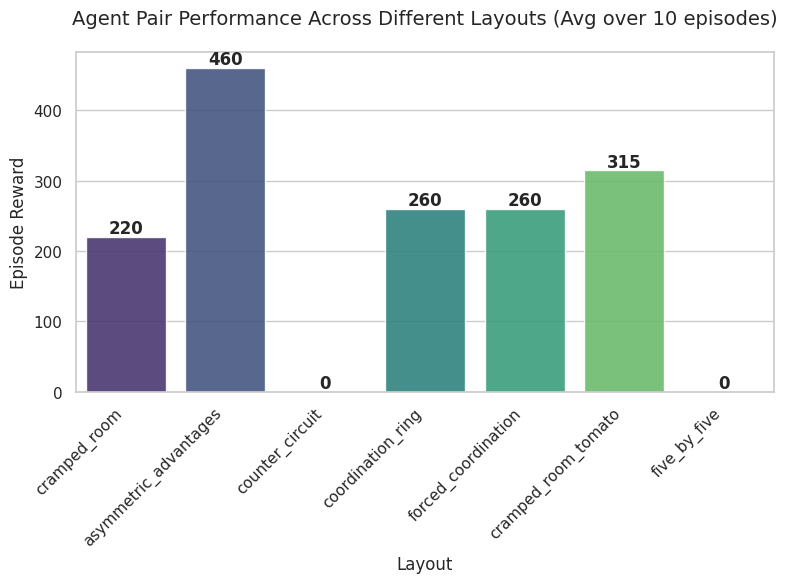

In [4]:
_, mean_rewards = eval_agent(agent_pair, eval_envs, seed=SEED, num_episodes=NUM_TEST_EPISODES)
plot_test_results(cfg.env_config.layouts, mean_rewards, NUM_TEST_EPISODES)

## Interactive Episode Visualization (Qualitative Analysis)

In [9]:
show_overcooked_episode(cfg, agent_pair, SEED)